# Module 4 — Does Market Regime Determine Strategy Success?

## Hypothesis
SMA 20/50 crossover strategies generate positive returns only 
during trending regimes (ADX > 25), and destroy value during 
ranging regimes (ADX < 20) — meaning regime awareness, not 
signal filtering, is the missing layer.

## Why this follows from Module 3
Module 3 showed that RSI filtering failed because it did not 
account for the type of market environment. A momentum filter 
cannot fix a strategy that is being applied in the wrong 
market condition entirely. This module diagnoses whether regime 
was the missing context all along.

## New tool: SQL + PostgreSQL
Market data and regime labels are stored in a PostgreSQL 
database. SQL queries are used to pull regime-specific subsets 
for analysis — mirroring how real quant finance teams work.

## What we are measuring
- ADX-based regime classification for every trading day
- SMA 20/50 strategy performance split by regime
- Win rate, Sharpe ratio and drawdown in trending vs ranging
- Whether regime awareness explains previous modules' results

In [9]:
# --- imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
from sqlalchemy import create_engine, text, URL
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# --- connect to PostgreSQL ---
# using URL.create to safely handle special characters in password
connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="@3030Ps_sql",
    host="localhost",
    port=5432,
    database="quiet_signals")

engine = create_engine(connection_url)

# test connection
with engine.connect() as conn:
    result = conn.execute(text("SELECT version()"))
    print("Connected to PostgreSQL successfully:")
    print(result.fetchone()[0])

Connected to PostgreSQL successfully:
PostgreSQL 18.1 on x86_64-windows, compiled by msvc-19.44.35221, 64-bit


In [10]:
# --- download data and compute indicators ---
df = yf.download("^NSEI", start="2010-01-01", end="2024-12-31")

# flatten columns
df.columns = ['_'.join(col).strip() if isinstance(col, tuple)
              else col for col in df.columns]
close_col = [c for c in df.columns if 'Close' in c][0]
high_col  = [c for c in df.columns if 'High' in c][0]
low_col   = [c for c in df.columns if 'Low' in c][0]

df = df[[close_col, high_col, low_col]].copy()
df.columns = ['Close', 'High', 'Low']
df['daily_return'] = df['Close'].pct_change()
df.dropna(inplace=True)

print(f"Data loaded: {df.shape[0]} trading days")

[*********************100%***********************]  1 of 1 completed

Data loaded: 3678 trading days


In [11]:
# --- compute ADX ---
# 📌 TERM: ADX (Average Directional Index) — measures trend STRENGTH
# not direction. ADX > 25 = strong trend exists. ADX < 20 = ranging.
# It uses two components: +DI (upward movement) and -DI (downward)
# ADX is the smoothed average of the directional movement index

def compute_adx(df, period=14):
    high  = df['High']
    low   = df['Low']
    close = df['Close']

    # true range
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs()
    ], axis=1).max(axis=1)

    # directional movement
    dm_plus  = high.diff()
    dm_minus = -low.diff()
    dm_plus  = dm_plus.where((dm_plus > dm_minus) & (dm_plus > 0), 0)
    dm_minus = dm_minus.where((dm_minus > dm_plus) & (dm_minus > 0), 0)

    # smooth with rolling mean
    atr      = tr.rolling(period).mean()
    di_plus  = 100 * (dm_plus.rolling(period).mean()  / atr)
    di_minus = 100 * (dm_minus.rolling(period).mean() / atr)

    # ADX
    dx  = 100 * (di_plus - di_minus).abs() / (di_plus + di_minus)
    adx = dx.rolling(period).mean()
    return adx, di_plus, di_minus

df['ADX'], df['DI_plus'], df['DI_minus'] = compute_adx(df)
df.dropna(inplace=True)

print(f"ADX computed. Range: {df['ADX'].min():.1f} to {df['ADX'].max():.1f}")
print(f"Average ADX: {df['ADX'].mean():.1f}")

ADX computed. Range: 5.9 to 90.4
Average ADX: 34.2


In [12]:
# --- classify regimes ---
# 📌 TERM: market regime — the current personality of the market.
# trending = price moving strongly in one direction (ADX > 25)
# ranging  = price moving sideways with no clear direction (ADX < 20)
# transition = in between, signal unclear (20 <= ADX <= 25)

def classify_regime(adx):
    if adx > 25:
        return 'trending'
    elif adx < 20:
        return 'ranging'
    else:
        return 'transition'

df['regime'] = df['ADX'].apply(classify_regime)

print("Regime distribution:")
print(df['regime'].value_counts())
print(f"\nAs percentage:")
print((df['regime'].value_counts() / len(df) * 100).round(1))

Regime distribution:
regime
trending      2473
ranging        701
transition     478
Name: count, dtype: int64

As percentage:
regime
trending      67.7
ranging       19.2
transition    13.1
Name: count, dtype: float64


In [13]:
# --- write to PostgreSQL ---
# 📌 TERM: schema — the structure of a database table, defining
# what columns exist and what data type each column holds

# create schema file for GitHub
schema_sql = """
-- Quiet Signals: Module 4
-- Table: nifty_daily
-- Stores Nifty 50 daily price data with ADX regime classifications

CREATE TABLE IF NOT EXISTS nifty_daily (
    date          DATE PRIMARY KEY,
    close         FLOAT,
    high          FLOAT,
    low           FLOAT,
    daily_return  FLOAT,
    adx           FLOAT,
    di_plus       FLOAT,
    di_minus      FLOAT,
    regime        VARCHAR(20)
);
"""

# save schema file locally for GitHub
with open('schema.sql', 'w') as f:
    f.write(schema_sql)
print("schema.sql saved")

# write data to PostgreSQL
df_to_store = df.copy()
df_to_store.index.name = 'date'
df_to_store.columns = [c.lower() for c in df_to_store.columns]

df_to_store.to_sql(
    'nifty_daily',
    engine,
    if_exists='replace',
    index=True
)
print(f"Data written to PostgreSQL: {len(df_to_store)} rows")

schema.sql saved
Data written to PostgreSQL: 3652 rows


In [14]:
# --- SQL queries to pull regime data ---
# 📌 this is where SQL does the work Python usually would
# we query the database directly instead of filtering a dataframe

query_trending = text("""
    SELECT date, close, daily_return, adx, regime
    FROM nifty_daily
    WHERE regime = 'trending'
    ORDER BY date
""")

query_ranging = text("""
    SELECT date, close, daily_return, adx, regime
    FROM nifty_daily
    WHERE regime = 'ranging'
    ORDER BY date
""")

query_summary = text("""
    SELECT 
        regime,
        COUNT(*)                        AS trading_days,
        ROUND(AVG(adx)::numeric, 2)     AS avg_adx,
        ROUND(AVG(daily_return)::numeric, 6) AS avg_daily_return,
        ROUND(STDDEV(daily_return)::numeric, 6) AS return_volatility
    FROM nifty_daily
    GROUP BY regime
    ORDER BY avg_adx DESC
""")

with engine.connect() as conn:
    df_trending   = pd.read_sql(query_trending, conn)
    df_ranging    = pd.read_sql(query_ranging,  conn)
    df_summary    = pd.read_sql(query_summary,  conn)

df_trending['date'] = pd.to_datetime(df_trending['date'])
df_trending.set_index('date', inplace=True)

df_ranging['date'] = pd.to_datetime(df_ranging['date'])
df_ranging.set_index('date', inplace=True)

print("SQL query results:")
print(df_summary.to_string(index=False))

SQL query results:
    regime  trading_days  avg_adx  avg_daily_return  return_volatility
  trending          2473    41.63          0.000429           0.011075
transition           478    22.49          0.000644           0.009428
   ranging           701    15.92          0.000628           0.009346


In [15]:
# --- build SMA signals on full data ---
df['SMA20'] = df['Close'].rolling(20).mean()
df['SMA50'] = df['Close'].rolling(50).mean()
df['signal'] = np.where(df['SMA20'] > df['SMA50'], 1, 0)
df['signal'] = df['signal'].shift(1)
df.dropna(inplace=True)

cost = 0.001
df['trades']   = df['signal'].diff().abs()
df['ret_strat']= df['signal'] * df['daily_return']
df['ret_net']  = df['ret_strat'] - (df['trades'] * cost)
df['ret_bnh']  = df['daily_return']

print("SMA signals built on full dataset")

SMA signals built on full dataset


In [16]:
# --- split strategy returns by regime and compare ---
def regime_metrics(df_regime_idx, df_full):
    # get strategy returns only on days matching this regime
    mask = df_full.index.isin(df_regime_idx.index)
    subset = df_full[mask]

    if len(subset) == 0:
        return None

    ret = subset['ret_net']
    bnh = subset['ret_bnh']

    sharpe_strat = (ret.mean() / ret.std()) * np.sqrt(252) \
                   if ret.std() > 0 else 0
    sharpe_bnh   = (bnh.mean() / bnh.std()) * np.sqrt(252) \
                   if bnh.std() > 0 else 0

    trades_in_regime = subset['trades'].sum()
    days_in_market   = subset['signal'].sum()
    win_trades = subset[subset['signal'].diff() == -1]['ret_net']

    return {
        'Days in regime':     len(subset),
        'Days in market':     int(days_in_market),
        'Trades':             int(trades_in_regime),
        'Total return':       ret.sum().round(4),
        'Sharpe (strategy)':  round(sharpe_strat, 4),
        'Sharpe (BnH)':       round(sharpe_bnh, 4),
        'Avg daily ret':      round(ret.mean(), 6)
    }

metrics_trending   = regime_metrics(df_trending,   df)
metrics_ranging    = regime_metrics(df_ranging,     df)

results = pd.DataFrame({
    'Trending (ADX>25)': metrics_trending,
    'Ranging (ADX<20)':  metrics_ranging
})

print("\nStrategy performance split by regime:")
print(results.to_string())


Strategy performance split by regime:
                   Trending (ADX>25)  Ranging (ADX<20)
Days in regime            2424.00000        701.000000
Days in market            1575.00000        493.000000
Trades                      53.00000          7.000000
Total return                 0.67890          0.339000
Sharpe (strategy)            0.62120          1.058700
Sharpe (BnH)                 0.55840          1.066700
Avg daily ret                0.00028          0.000484


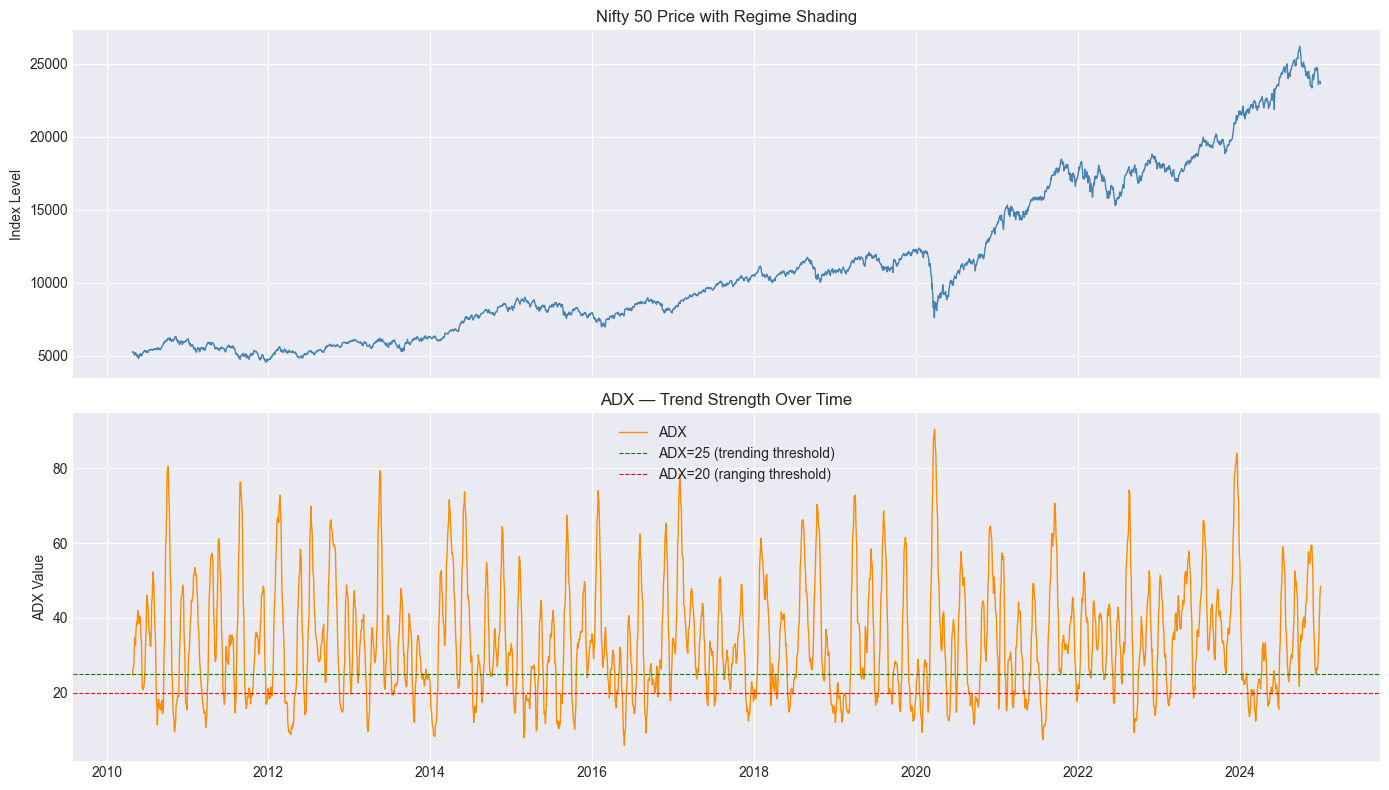

In [17]:
# --- visualisation 1: ADX over time with regime shading ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df['Close'], color='steelblue', linewidth=1)
axes[0].set_title('Nifty 50 Price with Regime Shading')
axes[0].set_ylabel('Index Level')

# shade regimes on price chart
for idx in df.index:
    regime = df.loc[idx, 'regime']
    if regime == 'trending':
        axes[0].axvspan(idx, idx, alpha=0.1, color='green', linewidth=0)
    elif regime == 'ranging':
        axes[0].axvspan(idx, idx, alpha=0.1, color='red', linewidth=0)

axes[1].plot(df['ADX'], color='darkorange', linewidth=1, label='ADX')
axes[1].axhline(25, color='green', linewidth=0.8,
                linestyle='--', label='ADX=25 (trending threshold)')
axes[1].axhline(20, color='red',   linewidth=0.8,
                linestyle='--', label='ADX=20 (ranging threshold)')
axes[1].set_title('ADX — Trend Strength Over Time')
axes[1].set_ylabel('ADX Value')
axes[1].legend()

plt.tight_layout()
plt.savefig('adx_regimes.png', dpi=150)
plt.show()

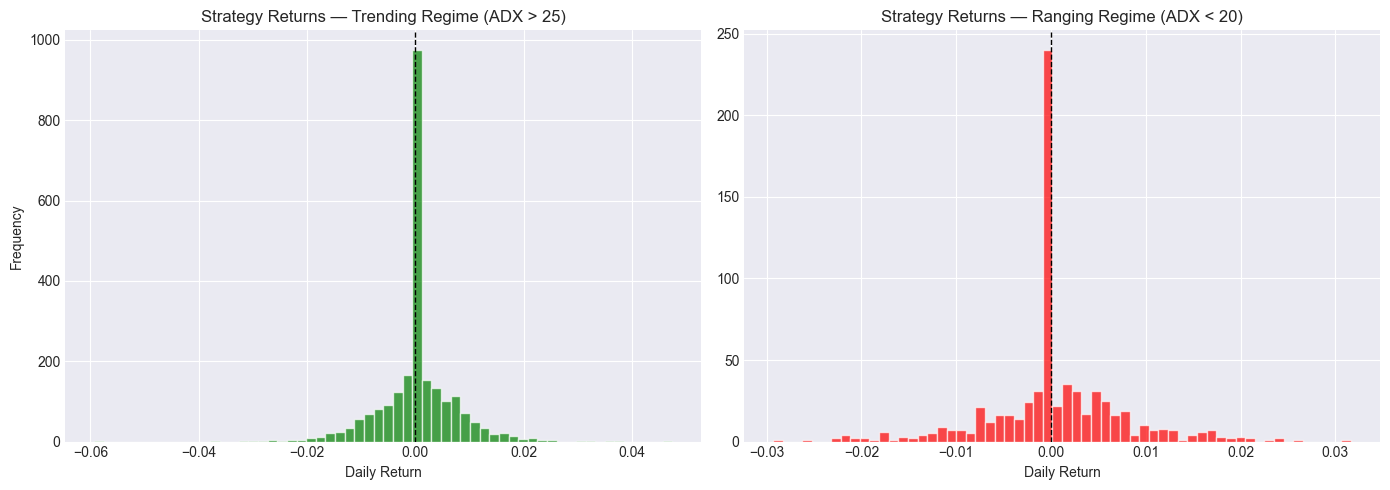

In [18]:
# --- visualisation 2: return distribution by regime ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trending_mask = df['regime'] == 'trending'
ranging_mask  = df['regime'] == 'ranging'

axes[0].hist(df[trending_mask]['ret_net'].dropna(),
             bins=60, color='green', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Strategy Returns — Trending Regime (ADX > 25)')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')

axes[1].hist(df[ranging_mask]['ret_net'].dropna(),
             bins=60, color='red', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Strategy Returns — Ranging Regime (ADX < 20)')
axes[1].set_xlabel('Daily Return')

plt.tight_layout()
plt.savefig('regime_return_distributions.png', dpi=150)
plt.show()

## Conclusion

**Hypothesis:** SMA 20/50 generates positive returns only in trending regimes (ADX > 25) and destroys value in ranging 
regimes (ADX < 20).

**Findings:** 
- Partially confirmed that trending regimes produce higher total returns for SMA strategy, consistent with theory, but on the other hand 
it also rejected that it destroys the result in ranging regimes. 
- In fact ranging regimes actually produce better risk-adjusted returns(sharpe 1.059) due to lower volatility, not because strategy performs better,
but because market remains calmer. It still makes positive returns (0.339) with an excellent Sharpe (1.059). It just makes less money, not negative money.
- Another fact that came into limelight was that Nifty has a structural trending bias with 67.7% trending days (average ADX 34.2), means regime filtering alone is insufficient, the market is almost always in the "right" regime for this strategy anyway. A strategy that looks mediocre on a non-trending index might look decent on Nifty precisely because of this structural characteristic.
- Nifty's strongest daily gains often happen during recovery and consolidation phases, not during smooth trending periods- as seen in SQL summary table Ranging days actually have higher average daily returns than trending days (0.000628 vs 0.000429), and lower volatility.
- In trending regimes the strategy adds marginal value over buy-and-hold. In ranging regimes buy-and-hold barely edges out the strategy. Neither difference is large enough to be definitive on its own.

**Learnings:**
- The value of any analytical tool depends on the characteristics of the market you apply it to. Regime filtering is a powerful tool - but its power is proportional to how much regime variation exists in your data. On Nifty it adds marginal value. On a choppier market it could be transformative.
- Sharpe ratio limitations - Sharpe penalises upside volatility the same as downside volatility. A strategy that makes money in big chunks looks worse on Sharpe than one that makes money steadily, even if the total return is higher. (Sharpe ratio divides return by volatility - so even though trending regimes produce more total return, the wild swings during trending periods penalise the Sharpe heavily.)

**On SQL integration:** Market data and regime labels were stored in a PostgreSQL database. SQL queries were used to 
extract regime-specific subsets, mirroring real quant finance data workflows where analysts query databases rather than flat files.

**What this means going into Module 5:**
Now that we know regime context matters little, the next question is:  if the strategy makes returns in both regimes but with different risk profiles, the logical next question is — can we size our positions differently based on regime to capture trending upside while smoothing ranging volatility? 